# VIVS: identifying genes that depend on the cellular niche

This tutorial demonstrates [VIVS](https://doi.org/10.1186/s13059-024-03419-z) {cite:p}`BoyeauVIVS24`, a conditional randomization test (CRT) that identifies which genes in a cell's expression profile are conditionally dependent on an external response of interest. VIVS learns (or reuses) a deep generative model of gene expression as a calibrated "knockoff" sampler, then tests whether an importance-score network can predict the response `Y` from the *true* expression better than from *knockoff* draws, yielding FDR-controlled p-values per gene (and, via a hierarchical extension, per gene cluster at several resolutions).

Here, `Y` is a niche-composition vector we compute directly from spatial coordinates (the cell-type composition of each cell's spatial neighborhood), and the knockoff sampler is a plain {class}`~scvi.model.SCVI` model trained on the raw counts — VIVS works with any generative model whose module is a `scvi.module.VAE` subclass (see {doc}`/user_guide/models/vivs` for the full compatibility table), not just spatially-aware ones.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import scanpy as sc
import scvi
from scvi.external import VIVS
from scvi.external.vivs import plot_hier_importance
from sklearn.neighbors import NearestNeighbors

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.5.0.post1


## Data loading

In this tutorial we load a human breast cancer section, generated with [10X Xenium](https://www.nature.com/articles/s41467-023-43458-x).
The cell segmentation originally performed on this data resulted in many erroneously assigned transcripts and therefore re-segmented the cells using the [ProSeg](https://www.biorxiv.org/content/10.1101/2024.04.25.591218v1) algorithm, which is a scalable algorithm for transcriptome-informed segmentation.

In [2]:
save_dir = tempfile.TemporaryDirectory()

adata_path = os.path.join(save_dir.name, "adata_for_tuto_s1.h5ad")
adata = sc.read(
    adata_path,
    backup_url="https://exampledata.scverse.org/scvi-tools/adata_for_tuto_s1.h5ad",
)
adata

  0%|          | 0.00/1.11G [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 117305 × 313
    obs: 'sample', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'n_counts', 'index', 'cell_type'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca'
    obsm: 'X_pca', 'X_scANVI', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'counts_log1p', 'counts_wo_bg', 'min_max_scaled', 'min_max_scaled_raw', None (.X)

## Compute the niche composition

VIVS needs a response `Y` to test gene expression against — here, for every cell, the cell-type composition of its `k`-nearest spatial neighbors ($k=20$), restricted to neighbors on the same slide (`sample`), since spatial coordinates aren't comparable across independent sections. This is a plain k-NN + one-hot-average computation, with no dependency on any particular generative model.

In [3]:
def compute_niche_composition(
    adata,
    k_nn: int = 20,
    sample_key: str = "sample",
    labels_key: str = "cell_type",
    cell_coordinates_key: str = "spatial",
    niche_composition_key: str = "niche_composition",
) -> None:
    """Compute, for every cell, the cell-type composition of its k-nearest spatial neighbors."""
    cell_types = adata.obs[labels_key].astype("category")
    one_hot = pd.get_dummies(cell_types).values.astype(np.float32)
    niche_composition = np.zeros((adata.n_obs, one_hot.shape[1]), dtype=np.float32)

    for sample in adata.obs[sample_key].unique():
        mask = (adata.obs[sample_key] == sample).values
        coords = adata.obsm[cell_coordinates_key][mask]
        n_neighbors = min(k_nn + 1, mask.sum())
        _, indices = NearestNeighbors(n_neighbors=n_neighbors).fit(coords).kneighbors(coords)
        # indices[:, 0] is always the cell itself; average over the remaining neighbors
        niche_composition[mask] = one_hot[mask][indices[:, 1:]].mean(axis=1)

    adata.obsm[niche_composition_key] = niche_composition


compute_niche_composition(adata, k_nn=20)

## Train a plain SCVI model

We register the `adata` and train a plain {class}`~scvi.model.SCVI` model to convergence. Its trained module will be reused below as VIVS's knockoff sampler, so VIVS itself will skip fitting its own generative VAE (phase 1) and go directly to testing `niche_composition` dependence (phase 2).

In [4]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",  # adata layer that contains the raw counts
    batch_key="sample",  # column in adata.obs that contains the batch covariate
)

scvi_model = scvi.model.SCVI(adata)
scvi_model.train(
    max_epochs=200,
    early_stopping=True,
    check_val_every_n_epoch=1,
    batch_size=512,
    plan_kwargs={
        "lr": 5e-4,
    },
)

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
You are using a CUDA device ('NVIDIA RTX 6000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
L

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


## Test niche-composition dependence with VIVS

We register the same `adata` for VIVS, with `y_obsm_key="niche_composition"` as the response `Y` whose dependence on gene expression `X` we want to test. Passing `x_model=scvi_model` tells VIVS to reuse the already-trained SCVI module (frozen) as its knockoff sampler, instead of fitting a new generative VAE — VIVS's `.train()` call then only fits the importance-score network for `Y | X`.

In [5]:
VIVS.setup_anndata(
    adata,
    y_obsm_key="niche_composition",  # cell-type composition of each cell's spatial neighborhood
    layer="counts",  # same raw-count layer used to train SCVI
    batch_key="sample",  # column in adata.obs that contains the batch covariate
)

vivs_model = VIVS(adata, x_model=scvi_model)
vivs_model.train(max_epochs=200)

INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 33 mo

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


## Hierarchical gene importance

`get_hier_importance` clusters genes by decoder-scale correlation at several resolutions, then re-runs the conditional randomization test with group-level knockoff substitution at each resolution, giving FDR-controlled p-values both for individual genes and for coarser gene clusters. Passing `n_clusters_list=[50, 100, 200]` tests three resolutions in addition to the finest (per-gene) one.

In [6]:
res = vivs_model.get_hier_importance(
    n_clusters_list=[50, 100, 200], batch_size=8192, n_mc_samples=100
)
res

Computing hierarchical importance:   0%|          | 0/200 [00:00<?, ?it/s]

[W909 13:26:37.587739852 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 3210739712 bytes (free: 1843068928, total: 50857967616).
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/external/vivs/_model.py:708: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(datasets, dim="resolution").reindex(gene_name=gene_order)


<xarray.Dataset> Size: 368kB
Dimensions:             (gene_name: 313, feature: 18, resolution: 4)
Coordinates:
  * gene_name           (gene_name) object 3kB 'NCAM1' 'KLRF1' ... 'ADAM9'
  * feature             (feature) int64 144B 0 1 2 3 4 5 6 ... 12 13 14 15 16 17
  * resolution          (resolution) int64 32B 50 100 200 313
    resolution_idx      (resolution) int64 32B 0 1 2 3
Data variables:
    pval                (resolution, gene_name, feature) float64 180kB 0.1782...
    padj                (resolution, gene_name, feature) float64 180kB 0.3564...
    cluster_assignment  (resolution, gene_name) int32 5kB 0 0 0 1 ... 85 284 3

## Visualizing results

`plot_hier_importance` renders the multi-resolution results as a significance dendrogram: genes/clusters found significant (BH-adjusted p-value below `significance_threshold`) at the coarsest resolution are shown, colored by significance, across all tested resolutions.

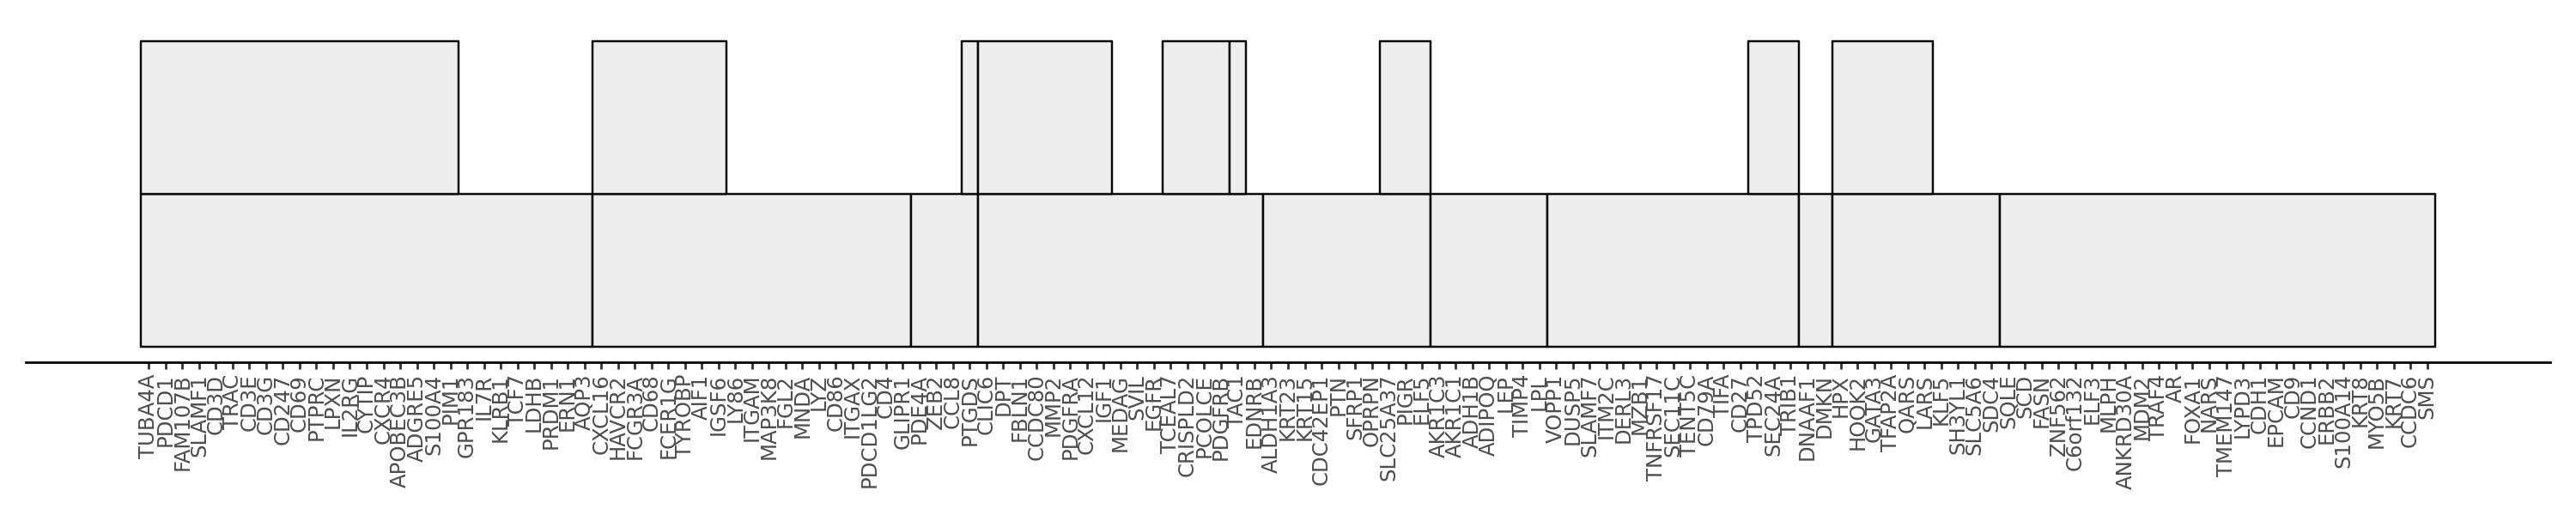

In [7]:
plot_hier_importance(res, theme_kwargs={"figure_size": (15, 3)})

In [15]:
# p-values on the held-out validation split (the default -- see `get_importance`'s docstring)
vivs_model_res = vivs_model.get_importance(indices=vivs_model.validation_indices, n_mc_samples=200)
pvalues = vivs_model_res["pvalues"][:, 0]

INFO     Generating sequential column names                                                                        


/tmp/ipykernel_984014/1511747290.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


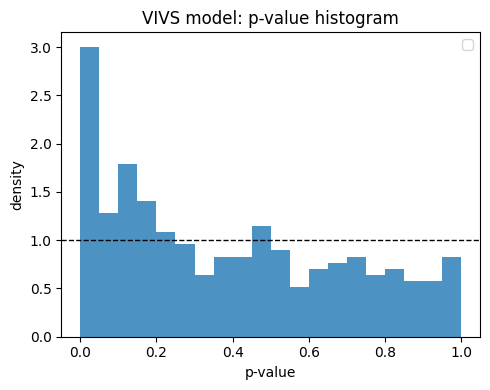

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(pvalues, bins=20, range=(0, 1), density=True, alpha=0.8)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("p-value")
ax.set_ylabel("density")
ax.set_title("VIVS model: p-value histogram")
ax.legend()
fig.tight_layout()
fig

## Interpretation and next steps

A gene (or gene cluster) called significant at a given resolution means the CRT rejected the null hypothesis that gene expression is conditionally independent of the niche composition `Y`, at the chosen FDR level, when knockoffs are drawn from SCVI's generative model — i.e. that gene's expression carries information about the surrounding niche beyond what is already explained by every other gene. Coarser resolutions (larger gene clusters) aggregate evidence across correlated genes and tend to have more power to detect weaker, distributed niche effects, while the finest (per-gene) resolution pinpoints individual genes.

For a per-cell rather than per-dataset view of which cells drive a given gene's (or gene cluster's) importance score, see {meth}`~scvi.external.VIVS.get_cell_scores`, which returns unsummed, per-cell importance scores for a chosen set of genes and responses.

## Sanity check: is VIVS calibrated on this data?

Ground truth is unknown for `niche_composition` on real data, so the significant genes found above cannot be directly checked against a known answer. To still validate that VIVS's p-values are calibrated *on this dataset* (same cell count, same expression noise, same batch structure), we build a **semi-synthetic response**: a nonlinear function of a handful of "true" genes' own expression, plus Gaussian noise. Genes not among these "true" genes are, by construction, conditionally independent of the response given the rest of the transcriptome — so under a well-calibrated CRT, their p-values (computed on the held-out validation split) should look ~`Uniform(0, 1)`, while the true genes' p-values should be very small.

This reuses the already-trained `scvi_model` as the knockoff sampler (as above), so only a new importance-score net needs to be fit.

In [8]:
N_TRUE_GENES = 5
rng = np.random.default_rng(0)

true_gene_idx = rng.choice(adata.n_vars, size=N_TRUE_GENES, replace=False)
x_true = adata.layers["counts_log1p"][:, true_gene_idx]
if hasattr(x_true, "todense"):
    x_true = np.asarray(x_true.todense())
x_true = x_true - x_true.mean(0, keepdims=True)

# nonlinear (quadratic) combination of the true genes, corrupted by Gaussian noise
y_synthetic = (x_true**2).sum(1, keepdims=True)
y_synthetic = y_synthetic + rng.normal(scale=y_synthetic.std() * 0.5, size=y_synthetic.shape)
adata.obsm["synthetic_niche"] = y_synthetic.astype(np.float32)

print("true genes:", adata.var_names[true_gene_idx].tolist())

true genes: ['MPO', 'KIT', 'CTSG', 'DNAAF1', 'SLAMF1']


In [9]:
VIVS.setup_anndata(
    adata,
    y_obsm_key="synthetic_niche",
    layer="counts",
    batch_key="sample",
)

calibration_model = VIVS(adata, x_model=scvi_model)
calibration_model.train(max_epochs=200)

INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: PossibleUserWarning: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorc

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [10]:
# p-values on the held-out validation split (the default -- see `get_importance`'s docstring)
calib_res = calibration_model.get_importance(
    indices=calibration_model.validation_indices, n_mc_samples=200
)
pvalues = calib_res["pvalues"][:, 0]

is_true_gene = np.isin(np.arange(adata.n_vars), true_gene_idx)
null_pvalues = pvalues[~is_true_gene]
print(f"null p-values: mean={null_pvalues.mean():.3f} (should be close to 0.5 if calibrated)")
print("true-gene p-values:", pvalues[is_true_gene])

null p-values: mean=0.528 (should be close to 0.5 if calibrated)
true-gene p-values: [0.00497512 0.00497512 0.00497512 0.00497512 0.00497512]


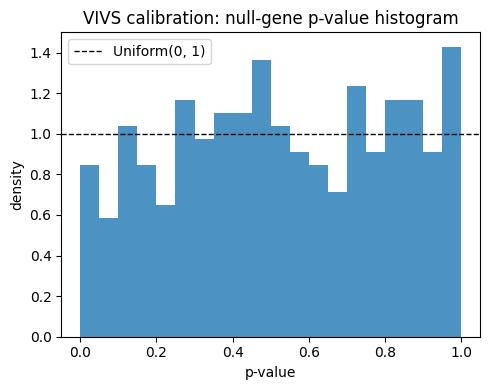

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(null_pvalues, bins=20, range=(0, 1), density=True, alpha=0.8)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Uniform(0, 1)")
ax.set_xlabel("p-value")
ax.set_ylabel("density")
ax.set_title("VIVS calibration: null-gene p-value histogram")
ax.legend()
fig.tight_layout()
fig